[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PerformanceEstimation/Tutorial-SIAM-OP26/blob/main/Part%203%20-%20Dual%2C%20proofs%2C%20and%20design/SIAM_MT_Part2.ipynb)

In [ ]:
!pip install pepit==0.5.1
!pip install sympy

# SIAM OP26 Minitutorial on performance estimation problems (part 2)

This notebook provides a simple example illustrating how to extract numerical values for the dual variables to analyze gradient descent in the smooth and strongly convex setting and to exploit them to obtain a worst-case performance bound.
The notebook further shows how to leverage those numerical findings to find and verify convergence proofs using SymPy. 

<a id="toc"></a>
## Table of Contents
- [1. Gradient descent, distance to a solution](#example1)
- [2. Using SymPy for the distance analysis](#example2)
- [3. Gradient descent, function value accuracy](#example3)
- [4. Designing a one-iteration optimal gradient descent](#example4)
- [5. Designing a two-iteration optimal gradient descent (silver stepsizes)](#example5)

In [10]:
# import PEPit and the required function class
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

# import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# set up the smoothness and strong convexity constant for the whole notebook
L, mu = 1, .1

##  1. Gradient descent, distance to a solution (numerical) <a class="anchor" id="example1"></a>

### 1.1. Primal PEP (numerical)

We start by a direct attempt: fix class parameters $L,\mu$ (chosen above) and experiment with different step size values $\gamma$. Verify that the obtained convergence rate is indeed smaller than one only when $\gamma\in\left(0,\frac{2}{L}\right)$. Further verify that it matches the very well-known $\max\{(1-\gamma L)^2,(1-\gamma\mu)^2\}$.

In [12]:
def wc_gradient_descent_distance(mu,L,gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1) #TODO OPERAND

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( (x1 - xs) ** 2 )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints # outputs optimal value and list of constraints (with their associated dual variables)

The following pieces of code compute and plot the numerical worst-case guarantees as a function of the tested step size value $\gamma$, for fixed $\mu,L$.

In [13]:
known_worst_case_value_function = lambda gamma: max((1 - gamma * L)**2, (1 - gamma * mu)**2)

In [14]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_distance(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(known_worst_case_value_function(gamma))

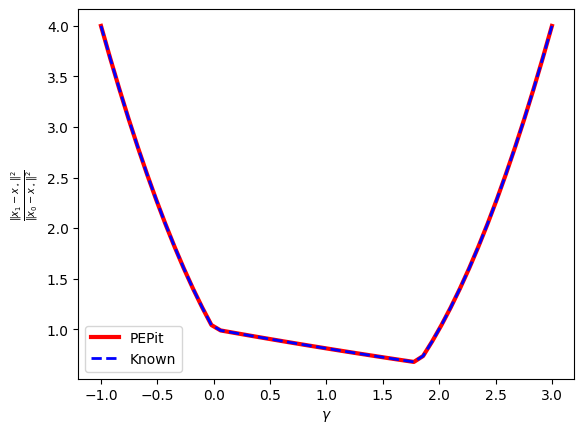

In [15]:
plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')
plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{\|x_1 - x_\star\|^2}{\|x_0 - x_\star\|^2}$')

plt.show()

One can admit that the match between PEPit's results and the known convergence rate is pretty good.

### 1.2. Dual PEP (numerical)

Let us also extract the dual variables. The next lines examplify how to do this extraction for given values of the parameters, and we integrate it in a loop for plotting below.

In [16]:
verbose = 0
gamma = 1/L

pepit_tau, list_of_constraints = wc_gradient_descent_distance(mu,L,gamma, verbose)

nb_cons = len(list_of_constraints)

for i in range(nb_cons):
    print('Constraint \"{}\" value: {}'.format(list_of_constraints[i].get_name(),
                                               list_of_constraints[i]._dual_variable_value))

Constraint "Performance metric 1" value: 1.0
Constraint "Initial condition" value: 0.8100000006611664
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_1)" value: 1.800009898700675
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_0)" value: 1.800009898700675


One can observe that the performance estimation problem is actually involving 4 constraints, 2 of which are of interest for us: the 3rd and 4th ones (that encode the fact the function is smooth and strongly convex). We can therefore extract their values in a loop, plot them, and expect their closed-forms to be nice. Perhaps one could even guess their values.

In [20]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_distance(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)

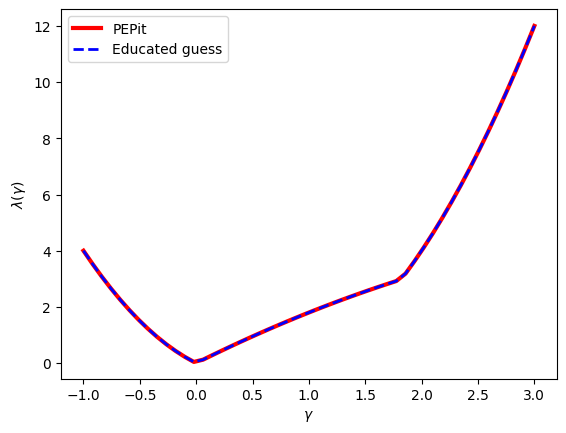

In [22]:
candidate_lambda = lambda gamma: max(abs(1-gamma*L),abs(1-gamma*mu))*2*abs(gamma)


candidate_lambda_list = [ candidate_lambda(gamma) for gamma in gamma_list ]
plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label='PEPit')
plt.plot(gamma_list, candidate_lambda_list, color='blue', linestyle='--', linewidth=2, label='Educated guess')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda(\gamma)$')

plt.show()

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## 2. Gradient descent, distance to a solution (symbolics) <a class="anchor" id="example2"></a>

This section requires [Sympy](https://www.sympy.org/en/index.html) (should have been installed in the beginning of the notebook via 
!pip install sympy).

In [23]:
import sympy as sm

### 2.1. Forming the LMI

First, we introduce symbols for the parameters

In [24]:
# create symbols for the problem parameters:
L = sm.Symbol('L')
mu = sm.Symbol('mu')
gamma = sm.Symbol('gamma')

Then, we introduce temporary symbols for the 'primal variables':

In [28]:
# create symbols for the "primal" variables:
x0 = sm.Symbol('x0')
g0 = sm.Symbol('g0')
f0 = sm.Symbol('f0')
xs = 0 # wlog, x_* = 0
gs = 0 # constraint g_* = 0
fs = 0 # wlog, f_* = 0

# define x1 using previous symbols:
x1 = x0 - gamma * g0  #TODO OPERAND

Then, we introduce the constraints and dual variables:

In [44]:
# the two interpolation constraints in the form "constraint <= 0"
constraint1 = f0 - fs + g0*(xs-x0) + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
constraint2 = fs - f0 + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
# the objective and the "initial condition" constraint: (also in the form "constraint <= 0")
primal_objective = (x1-xs)**2
initial_condition = (x0-xs)**2-1

# create symbols for the "dual" variables
tau = sm.Symbol('tau')
l1 = sm.Symbol('lambda_1')
l2 = sm.Symbol('lambda_2')

Finally, we write the Lagrangian

In [45]:
# Lagrangian:
Lagrangian = primal_objective - l1*constraint1 - l2*constraint2 - tau * initial_condition

Since our expressions are quadratic in (x0,g0), the LMI is actually given by the Hessian of the Lagrangian wrt (x0,g0).
Alternatively, one can compute the matrices $A_i$ and vectors $b_i$ that would encode the constraints as $\mathrm{Tr}(A_i G)+b_i^T F\leq 0$.

In [46]:
# This is the LMI:
LMI = sm.simplify(sm.hessian( -Lagrangian , (x0,g0))/2)


LMI # Should this matrix be PSD or NSD?

Matrix([
[(L*lambda_1*mu/2 + L*lambda_2*mu/2 + (L - mu)*(tau - 1))/(L - mu),         (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu)],
[        (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu), (4*gamma**2*(-L + mu) + 2.0*lambda_1 + 2.0*lambda_2)/(4*(L - mu))]])

Similarly, the linear constraint on the dual is the gradient wrt f0 (since $f_\star$ is fixed to $0$)

In [47]:
# This is the linear constraint ==0 in the LMI
LinearConst = sm.simplify(sm.diff(-Lagrangian,f0))

LinearConst # show linear constraint (==0)

lambda_1 - lambda_2

#### Verify that our candidate multipliers produce dual feasible points

For simplicity, set $\gamma=\tfrac1L$. What are the corresponding values for your candidates $\tau$ and $\lambda_1,\lambda_2$?

In [62]:
# Specialize the LMI to gamma=1/L

fixed_gamma = 1/L
LMI_fixed_gamma = sm.simplify(LMI.subs(gamma,fixed_gamma))

LMI_fixed_gamma

Matrix([
[(L*lambda_1*mu/2 + L*lambda_2*mu/2 + (L - mu)*(tau - 1))/(L - mu),   (-L*(L*lambda_1 + lambda_2*mu)/2 + L - mu)/(L*(L - mu))],
[          (-L*(L*lambda_1 + lambda_2*mu)/2 + L - mu)/(L*(L - mu)), (0.5*L**2*(lambda_1 + lambda_2) - L + mu)/(L**2*(L - mu))]])

In [63]:
# Specialize the LMI to gamma=1/L

candidate_expression_lambda = 2 * fixed_gamma * (1 - mu * fixed_gamma)
candidate_expression_tau = (1 - mu * fixed_gamma )**2

LMI_simplified = sm.simplify(LMI_fixed_gamma.subs(l2,l1))
LMI_simplified = sm.simplify(LMI_simplified.subs(l1,candidate_expression_lambda))
LMI_simplified = sm.simplify(LMI_simplified.subs(tau,candidate_expression_tau))
LMI_simplified

Matrix([
[mu**2/L**2, -mu/L**2],
[  -mu/L**2, 1.0/L**2]])

Is this matrix PSD? What do we conclude?

In [64]:
LMI_simplified.eigenvals()

{1.0*(mu**2 + 1)/L**2: 1, 0: 1}

### 2.2. An equivalent proof without (explicit) SDPs

In [67]:
# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')

# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero

# dual variables
tau = (1 - mu * gamma)**2
l1 = 2 * gamma * (1 - mu * gamma)
l2 = l1

# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)

# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
performance_measure = (x1 - xs)**2
initial_condition = (x0 - xs)**2 

# Weighted sum
weighted_sum = l1 * constraint1 + l2 * constraint2

# Reformulation
reformulation = performance_measure - tau * initial_condition + gamma * (2 - gamma * (L + mu))/(L - mu) * (mu * (x0 - xs) - g0)**2

# Verify equivalence
residual = sm.simplify(weighted_sum - reformulation)
residual

0

**Bonus**: solving the linear matrix inequalities without numerical hints. While not always easy

## 3. Gradient descent, function value accuracy <a class="anchor" id="example3"></a>

Let us continue with the a similar exercise, but now by changing the specific quantity under our radar to function values. Practically speaking, this means changing both the performance metric and the initial condition in the previous code. Executing the code in the same fashion as before, we observe the exact same worst-case ratios.

In [27]:
L, mu = 1, .1

In [28]:
def wc_gradient_descent_function_values(mu, L, gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition( f(x0) - fs <= 1) #TODO OPERAND

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f(x1) - fs )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints # outputs optimal value and list of constraints (with their associated dual variables)

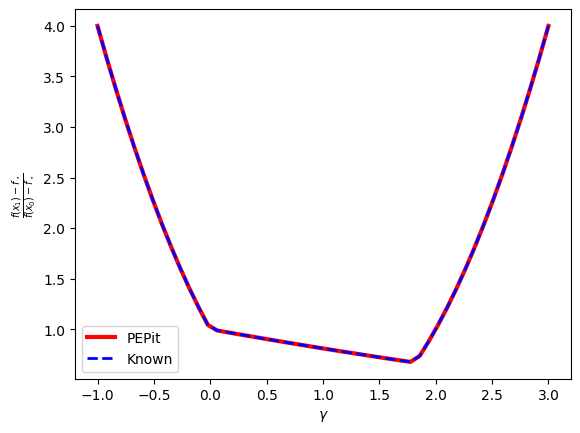

In [29]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_function_values(mu, L, gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))

plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{f(x_1) - f_\star}{f(x_0) - f_\star}$')

plt.show()

However, a bad surprise appears when inspecting the problem: there are actually more constraints, and hence possibly more dual multipliers to be identified. We do not describe here the reason for this difference (more constraints, explained at length, e.g., in [this blog post](https://francisbach.com/computer-aided-analyses/) or this [habilitation thesis](https://hal.science/tel-04794552v2/file/HDR_ATaylor_V_HAL2.pdf)) and instead focus on the consequences. First, let us investigate a bit the values of those (additional) dual variables.

In [30]:
verbose = 0
gamma = 1/L

pepit_tau, list_of_constraints = wc_gradient_descent_function_values(mu,L,gamma, verbose)

nb_cons = len(list_of_constraints)

for i in range(nb_cons):
    print('Constraint \"{}\" value: {}'.format(list_of_constraints[i].get_name(),
                                               list_of_constraints[i]._dual_variable_value))

Constraint "Performance metric 1" value: 1.0
Constraint "Initial condition" value: 0.8099999034654997
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_1)" value: 0.04318494581205349
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_2)" value: 0.14690493317815176
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_0)" value: 3.7068368407529674e-05
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_2)" value: 1.3215023299277147
Constraint "IC_Function_0_smoothness_strong_convexity(Point_2, Point_0)" value: 5.272685701848342e-05
Constraint "IC_Function_0_smoothness_strong_convexity(Point_2, Point_1)" value: 0.46835454902147894


To get a clearer picture, let us plot all these values as a function of $\gamma$ again. The code below is intentionally a bit raw for readability purposes---there are six dual variables to explore.

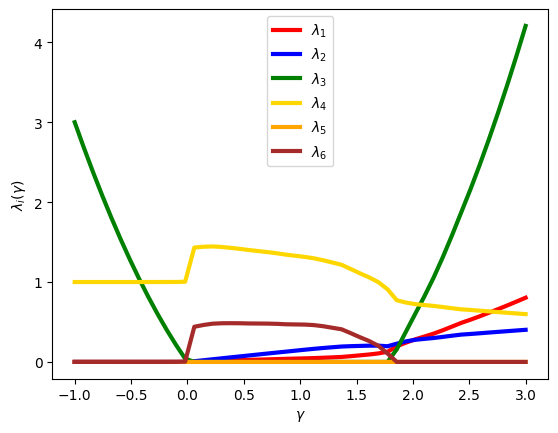

In [31]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()
pepit_dual_value3 = list()
pepit_dual_value4 = list()
pepit_dual_value5 = list()
pepit_dual_value6 = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_function_values(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)
    pepit_dual_value3.append(list_of_constraints[4]._dual_variable_value)
    pepit_dual_value4.append(list_of_constraints[5]._dual_variable_value)
    pepit_dual_value5.append(list_of_constraints[6]._dual_variable_value)
    pepit_dual_value6.append(list_of_constraints[7]._dual_variable_value)


plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label=r'$\lambda_1$')
plt.plot(gamma_list, pepit_dual_value2, color='blue', linestyle='-', linewidth=3, label=r'$\lambda_2$')
plt.plot(gamma_list, pepit_dual_value3, color='green', linestyle='-', linewidth=3, label=r'$\lambda_3$')
plt.plot(gamma_list, pepit_dual_value4, color='gold', linestyle='-', linewidth=3, label=r'$\lambda_4$')
plt.plot(gamma_list, pepit_dual_value5, color='orange', linestyle='-', linewidth=3, label=r'$\lambda_5$')
plt.plot(gamma_list, pepit_dual_value6, color='brown', linestyle='-', linewidth=3, label=r'$\lambda_6$')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda_i(\gamma)$')

plt.show()

In [32]:
def wc_gradient_descent_function_values_sparse_proof(mu,L,gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition( f(x0) - fs <= 1)

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f(x1) - fs )

    # Output prepared problem
    pepit_verbose = max(verbose, 0)
    problem._prepare_constraints(verbose=pepit_verbose)
    
    # Complete below: what constraints should be deactivated?
    ################## TODO BLOCK
    problem._list_of_prepared_constraints[4].deactivate()
    problem._list_of_prepared_constraints[6].deactivate()
    problem._list_of_prepared_constraints[7].deactivate()
    ################## END TODO BLOCK


    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints


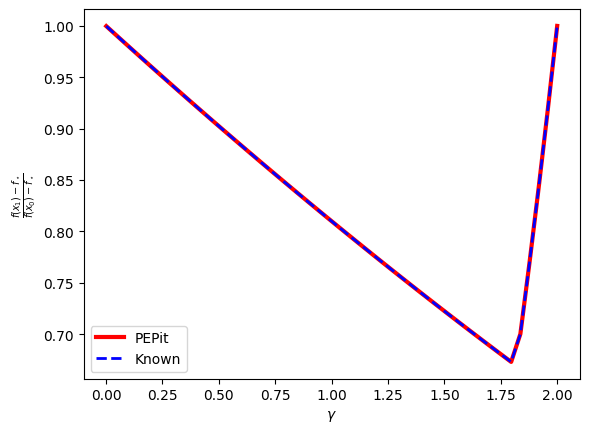

In [33]:
verbose = 0

gamma_min, gamma_max = 0.001, 2 # only test the step sizes of interest here
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_function_values_sparse_proof(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))

plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{f(x_1) - f_\star}{f(x_0) - f_\star}$')

plt.show()

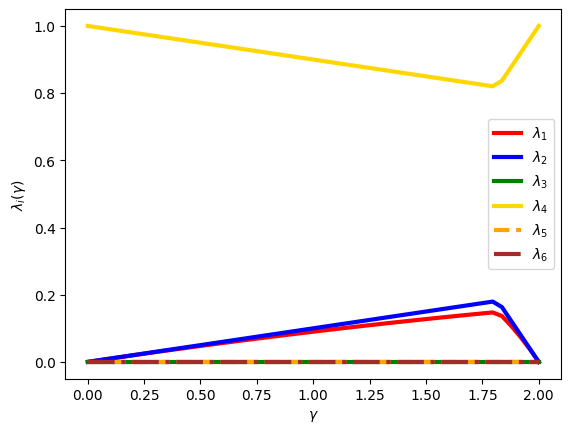

In [34]:
verbose = 0

gamma_min, gamma_max = 0.001, 2
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()
pepit_dual_value3 = list()
pepit_dual_value4 = list()
pepit_dual_value5 = list()
pepit_dual_value6 = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_function_values_sparse_proof(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)
    pepit_dual_value3.append(list_of_constraints[4]._dual_variable_value)
    pepit_dual_value4.append(list_of_constraints[5]._dual_variable_value)
    pepit_dual_value5.append(list_of_constraints[6]._dual_variable_value)
    pepit_dual_value6.append(list_of_constraints[7]._dual_variable_value)


plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label=r'$\lambda_1$')
plt.plot(gamma_list, pepit_dual_value2, color='blue', linestyle='-', linewidth=3, label=r'$\lambda_2$')
plt.plot(gamma_list, pepit_dual_value3, color='green', linestyle='-', linewidth=3, label=r'$\lambda_3$')
plt.plot(gamma_list, pepit_dual_value4, color='gold', linestyle='-', linewidth=3, label=r'$\lambda_4$')
plt.plot(gamma_list, pepit_dual_value5, color='orange', linestyle='--', linewidth=3, label=r'$\lambda_5$')
plt.plot(gamma_list, pepit_dual_value6, color='brown', linestyle='-.', linewidth=3, label=r'$\lambda_6$')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda_i(\gamma)$')

plt.show()

Well, guessing closed-forms appears like a much more challenging game! Before actually going into the search for closed-forms, we need to simplify the problem; this is not done here, but the interested reader can check [this more complete notebook (Section 3)](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extracting_a_proof.ipynb).

## 4. Designing an optimal gradient descent (one iteration) <a class="anchor" id="example4"></a>

Start with a few imports used throughout this section.

In [35]:
# import PEPit and the required function class
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

# import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from math import sqrt

### 4.1. Back to base gradient descent: numerical experiments

We first consider a direct approach: fix the class parameters $L, \mu$ (chosen below) and experiment with different step sizes $\gamma$. Verify that the resulting convergence rate is smaller than one only when $\gamma \in \left(0, \frac{2}{L}\right)$, and that it matches the well-known bound $\max\left\{(1-\gamma L)^2,\, (1-\gamma\mu)^2\right\}$.

The following code is standard and was already introduced in the previous exercise sessions.

In [36]:
# 1) write GD PEP

def wc_gradient_descent(L, mu, gammas, verbose = 0):
    
    n = len(gammas)
    
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name='xs')

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name='x0')

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    for i in range(n):
        x = x - gammas[i] * func.gradient(x)
        x.set_name('x{}'.format(i+1))

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( (x - xs) ** 2 )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints


    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau, list_of_constraints, func.get_class_constraints_duals(), problem.residual

We now verify the rate for $(\mu, L) = (0.1, 1)$ over a grid of step sizes.

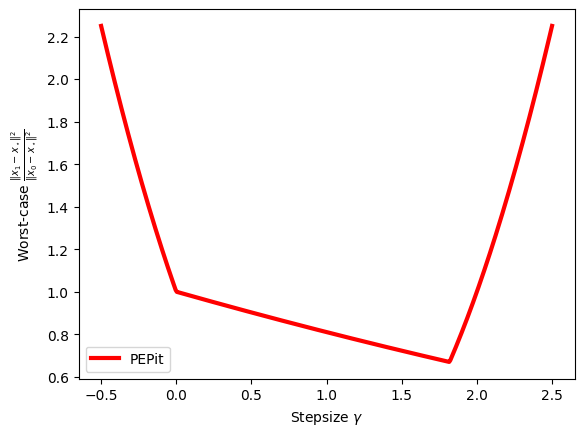

In [37]:
L = 1.
mu = .1
gamma_min, gamma_max = -.5, 2.5
nb_gammas = 400
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()

for i, gamma in enumerate(gamma_list):
    pepit_tau, _, _, _ = wc_gradient_descent(mu=mu,L=L,gammas=[gamma])
    pepit_worst_case_value.append(pepit_tau)
    print(f'{i + 1} / {nb_gammas} grid points computed', end='\r', flush=True)
    
plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.legend()
plt.xlabel(r'Stepsize $\gamma$')
plt.ylabel(r'Worst-case $\frac{\|x_1-x_\star\|^2}{\|x_0-x_\star\|^2}$')

plt.show()

In [38]:
pepit_tau, _, _, _ = wc_gradient_descent(L=L,mu=mu,gammas=[1/L])
[pepit_tau]

[0.8100000006611664]

Identify the pattern in the inequalities: does it make sense, and can you explain it in light of the PEP theory you know?

In [40]:
pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(1, .1, [1/L])

print(tab["smoothness_strong_convexity"])

IC_Function_0       xs       x0
xs             0.00000  1.80001
x0             1.80001  0.00000


Are there other active constraints? (note: you can ignore the "performance metric" constraint for now)

In [41]:
for i, constraint in enumerate(list_of_constraints):
    print('Constraint \"{}\" value: {}'.format(constraint.get_name(),
                                               constraint._dual_variable_value))

Constraint "Performance metric 1" value: 1.0
Constraint "Initial condition" value: 0.8100000006611664
Constraint "IC_Function_0_smoothness_strong_convexity(xs, x0)" value: 1.800009898700675
Constraint "IC_Function_0_smoothness_strong_convexity(x0, xs)" value: 1.800009898700675


Now, our goal is to compute the optimal point by observing a few properties of the corresponding PEP objects, assuming we do not already know that its parametric value is $2/(L+\mu)$. In particular, observe the value of the residual matrix (at the best point of the grid) and compare it with its value for other step sizes. Can you explain this intuitively? Does it give you a hint on how to algebraically characterize this optimal step size?

In [42]:
# index of the best stepsize using np.argmin():
idx_best = np.argmin(pepit_worst_case_value) #TODO OPERAND
gamma_best = gamma_list[idx_best]
tau_best = pepit_worst_case_value[idx_best]

pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(L=L, mu=mu, gammas=[gamma_best])

print(res)

[[ 5.31817505e-05 -5.31798584e-05  5.31383717e-04]
 [-5.31798584e-05  5.31817505e-05 -5.31383717e-04]
 [ 5.31383717e-04 -5.31383717e-04  5.31014805e-03]]


Now that you understand some algebraic properties of the optimal step size, let us try to compute it directly via symbolic computations (using SymPy).

### 4.2. Rediscovering optimal parameters for gradient descent 

In [43]:
# Proof with SymPy :)
import sympy as sm


# We start by writing the SDP in dual form:

# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')
# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero
# dual variables
tau, l1, l2 = sm.symbols('tau lambda_1 lambda_2')
# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)
# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
primal_objective = (x1 - xs)**2
initial_condition = (x0 - xs)**2 - 1

# Lagrangian
Lagrangian = (
    - l1 * constraint1
    - l2 * constraint2
    - tau * initial_condition
    + primal_objective
)

# Linear matrix inequality (aka. residual on the dual side):
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0)) / 2)
# Linear constraint
Linear = sm.diff(-Lagrangian, f0)

We can now proceed step by step to cancel both terms, namely the LMI/residual and the linear constraint. We show below how to do everything at once, but the step-by-step approach is pedagogically useful and helps one get used to SymPy:

In [44]:
LMI

Matrix([
[(L*lambda_1*mu/2 + L*lambda_2*mu/2 + (L - mu)*(tau - 1))/(L - mu), (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu)],
[        (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu), (2*gamma**2*(-L + mu) + lambda_1 + lambda_2)/(2*(L - mu))]])

In [45]:
Linear

lambda_1 - lambda_2

In [46]:
# first: substitute one dual variable by the other (as the linear constraint forces them to be equal)
LMI = LMI.subs(l2,l1)
LMI

Matrix([
[            (L*lambda_1*mu + (L - mu)*(tau - 1))/(L - mu), (-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu)],
[(-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu),          (2*gamma**2*(-L + mu) + 2*lambda_1)/(2*(L - mu))]])

In [47]:
# Then: pick tau so as to cancel out first entry of the LMI:
tau_val = sm.solve(LMI[0,0],tau)
LMI = sm.simplify(LMI.subs(tau,tau_val[0]))
LMI

Matrix([
[                                                        0, (-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu)],
[(-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu),                  (gamma**2*(-L + mu) + lambda_1)/(L - mu)]])

In [48]:
# Then: pick \lambda_1 to cancel out the off-diagonal term:
l1_val = sm.solve(LMI[1,0],l1)
LMI = sm.simplify(LMI.subs(l1,l1_val[0]))
LMI

Matrix([
[0,                                    0],
[0, gamma*(-gamma*(L + mu) + 2)/(L + mu)]])

In [49]:
# Then: pick gamma to cancel out the last term:
gamma_val = sm.solve(LMI[1,1],gamma) #TODO OPERAND
LMI = sm.simplify(LMI.subs(gamma,gamma_val[0]))

# The optimal step size is thus one among the two solutions:
print('There are {} possible solutions'.format(len(gamma_val)))
print('Either gamma={},'.format(gamma_val[0]))
print('or gamma={}.'.format(gamma_val[1]))

There are 2 possible solutions
Either gamma=0,
or gamma=2/(L + mu).


Nice: this is very much in line with what one would expect.
The next lines perform exactly the same operations, but all at once.

In [51]:
# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')
# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero
# dual variables
tau, l1, l2 = sm.symbols('tau lambda_1 lambda_2')
# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)
# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
primal_objective = (x1 - xs)**2
initial_condition = (x0 - xs)**2 - 1

# Lagrangian
Lagrangian = (
    - l1 * constraint1
    - l2 * constraint2
    - tau * initial_condition
    + primal_objective
)

# LMI
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0)) / 2)
Linear = sm.simplify(sm.diff(-Lagrangian,f0))
#LMI = LMI.subs(l2,l1)

sols = sm.solve([LMI,Linear],tau,l1,l2,gamma)

In [52]:
sols[1]

((L - mu)**2/(L + mu)**2,
 4*(L - mu)/(L + mu)**2,
 4*(L - mu)/(L + mu)**2,
 2/(L + mu))

A natural next question is how to turn these findings into a proof of the result:

Method: $x_1=x_0-\gamma \nabla f(x_0)$. The optimal step size is $\tfrac{2}{L+\mu}$, and the proof is as follows. Consider the weighted sum of

- interpolation between $x_0$ and $x_\star$ with weight $\lambda_1=2\gamma (1-\gamma\mu)$
- interpolation between $x_\star$ and $x_0$ with weight $\lambda_2=\lambda_1$

The weighted sum gives (by completing the squares; a.k.a., "analytical Cholesky"):
$$\|x_1-x_\star\|^2\leq (1-\gamma \mu)^2 \|x_0-x_\star\|^2 - \tfrac{\gamma(2-\gamma(L+\mu))}{L-\mu}\|\mu (x_0-x_\star)-\nabla f(x_0)\|^2.$$

Cancelling the last term, we obtain the value for $\gamma$, and the rate $\left(\frac{L-\mu}{L+\mu}\right)^2$.

## 5. Multistep gradient descent (aka the Silver step-size schedule [5]) <a class="anchor" id="example5"></a>

Let us now consider the same optimization setup: we want to minimize a smooth strongly convex function
$$ \min_{x\in\mathbb{R}^d} f(x),$$
but using a multistep gradient algorithm. That is, we will iterate:
\begin{align*}
x_{1} &= x_0 - \gamma_1 \nabla f(x_0),\\
x_{2} &= x_1 - \gamma_2 \nabla f(x_1),
\end{align*}
and our goal will be to design the pair $(\gamma_1, \gamma_2)$. We proceed with the following choice:

$$\min_{\gamma_1,\gamma_2}\,\, \max_{f\in\mathcal{F}_{\mu,L}} \left\{ \frac{\|x_2-x_\star\|^2_2}{\|x_0-x_\star\|^2_2} \, : \, x_2 \text{ obtained from } x_{1} = x_0 - \gamma_1 \nabla f(x_0),\,x_{2} = x_1 - \gamma_2 \nabla f(x_1)  \right\}.$$


To do this, we will follow steps similar to those used for vanilla GD.

For simplicity, let us again carry out the analysis for specific parameter values.

In [53]:
L, mu = 1, .1

### 5.1. Numerical exploration

In [54]:
def pepit_grid_search(gamma1_grid, gamma2_grid, mu, L):
    """
    Evaluate wc_gradient_descent on a grid of (gamma1, gamma2).

    Parameters
    ----------
    gamma1_grid : array-like
        Grid values for gamma1.
    gamma2_grid : array-like
        Grid values for gamma2.
    mu, L : float
        Problem parameters.

    Returns
    -------
    G1, G2 : ndarray
        Meshgrid of gamma1 and gamma2.
    tau_grid : ndarray
        Grid of pepit_tau values.
    """

    G1, G2 = np.meshgrid(gamma1_grid, gamma2_grid)
    tau_grid = np.zeros_like(G1)

    total = tau_grid.size

    for k, (i, j) in enumerate(np.ndindex(G1.shape), start=1):
        gamma1 = G1[i, j]
        gamma2 = G2[i, j]

        pepit_tau, _, _, _ = wc_gradient_descent(mu=mu, L=L, gammas=[gamma1, gamma2])
        tau_grid[i, j] = pepit_tau

        print(f'{k} / {total} grid points computed', end='\r', flush=True)

    return G1, G2, tau_grid

def plot_pepit_landscape(G1, G2, tau_grid):
    """
    Plot the contour landscape of pepit_tau and highlight the minimum.

    Parameters
    ----------
    G1, G2 : ndarray
        Meshgrid of gamma1 and gamma2.
    tau_grid : ndarray
        Grid of pepit_tau values.

    Returns
    -------
    i_best, j_best : int
        Indices of the best grid point.
    gamma1_best, gamma2_best : float
        Best step sizes.
    tau_best : float
        Best value of pepit_tau.
    """

    plt.figure()

    levels = np.logspace(
        np.log10(np.nanmin(tau_grid)),
        np.log10(np.nanmax(tau_grid)),
        50
    )

    cf = plt.contourf(
        G1, G2, tau_grid,
        levels=levels,
        cmap='viridis_r',
        norm=LogNorm()
    )

    plt.colorbar(cf)

    # locate minimum
    idx = np.nanargmin(tau_grid)
    i_best, j_best = np.unravel_index(idx, tau_grid.shape)

    gamma1_best = G1[i_best, j_best]
    gamma2_best = G2[i_best, j_best]
    tau_best = tau_grid[i_best, j_best]

    # mark minimum
    plt.scatter(gamma1_best, gamma2_best, s=120, color='red',
                edgecolor='black', zorder=3)

    plt.xlabel(r'$\gamma_1$')
    plt.ylabel(r'$\gamma_2$')
    plt.title(r'Worst-case $\frac{\|x_2-x_\star\|^2}{\|x_0-x_\star\|^2}$')

    plt.show()

    print(f"Best grid index: (i,j) = ({i_best}, {j_best})")
    print(f"gamma1 = {gamma1_best:.4f}, gamma2 = {gamma2_best:.4f}")
    print(f"tau = {tau_best:.4e}")

    return i_best, j_best, gamma1_best, gamma2_best, tau_best

Using the previous pieces of code, perform a grid search over the step sizes and plot the corresponding convergence rate values.

In [55]:
# 4) plot (2-step)
gamma_min, gamma_max = 0.1, 3.2
nb_gammas = 30

gamma1_vals = np.linspace(gamma_min, gamma_max, nb_gammas)
gamma2_vals = gamma1_vals

G1, G2, tau_grid = pepit_grid_search(gamma1_vals, gamma2_vals, mu=mu, L=L)

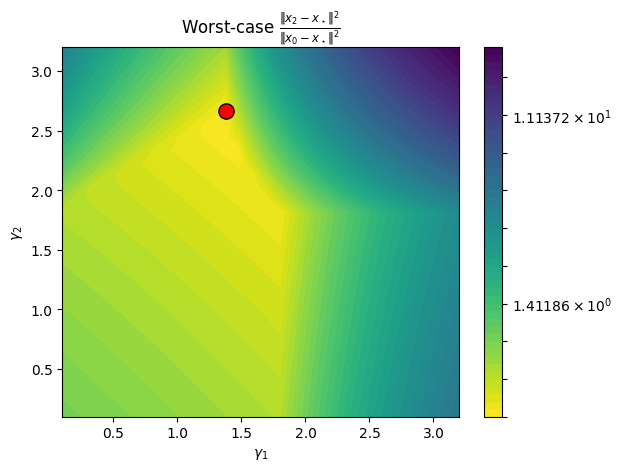

Best grid index: (i,j) = (24, 12)
gamma1 = 1.3828, gamma2 = 2.6655
tau = 4.0889e-01


In [56]:
_, _, gamma1_best, gamma2_best, tau_best = plot_pepit_landscape(G1, G2, tau_grid)

As we want to find properties of the optimal point, let us refine the grid around the target point (possibly several times)!

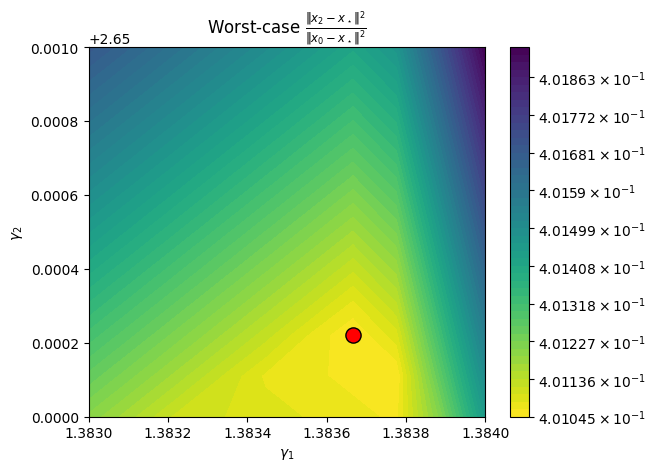

Best grid index: (i,j) = (2, 6)
gamma1 = 1.3837, gamma2 = 2.6502
tau = 4.0105e-01


In [57]:
gamma1_min, gamma1_max = 1.383, 1.384 #TODO OPERAND
gamma2_min, gamma2_max = 2.650, 2.651 #TODO OPERAND
nb_gammas = 10

gamma1_vals = np.linspace(gamma1_min, gamma1_max, nb_gammas)
gamma2_vals = np.linspace(gamma2_min, gamma2_max, nb_gammas)

G1, G2, tau_grid = pepit_grid_search(gamma1_vals, gamma2_vals, mu=mu, L=L)
_, _, gamma1_best, gamma2_best, tau_best = plot_pepit_landscape(G1, G2, tau_grid)

What algebraic property do you empirically observe at (or around) this optimal point?

In [58]:
pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(L=L, mu=mu, gammas=[gamma1_best, gamma2_best])

print(res)

[[ 6.30881589e-07 -6.29076105e-07  3.14310383e-06  3.50857270e-06]
 [-6.29076105e-07  6.30880714e-07 -3.14310387e-06 -3.50857831e-06]
 [ 3.14310383e-06 -3.14310387e-06  1.03059809e-04 -8.41503948e-05]
 [ 3.50857270e-06 -3.50857831e-06 -8.41503948e-05  1.38271517e-04]]


In order to help SymPy, we also have to identify the sparsity pattern for the dual variables. What do you observe and how would you choose it?

In [59]:
print(tab["smoothness_strong_convexity"])

IC_Function_0        xs        x0        x1
xs             0.000000  1.159250  4.231348
x0             0.000020  0.000000  2.090086
x1             5.390578  0.930856  0.000000


### 5.2. Exploiting numerical observations to design the algorithm.

Use SymPy to try to compute the optimal step sizes.

In [67]:
# problem parameters
L, mu, gamma1, gamma2 = sm.symbols('L mu gamma1 gamma2', positive=True)

# primal variables
x0, g0, g1, f0, f1 = sm.symbols('x0 g0 g1 f0 f1')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero𝑖

x1 = x0 - gamma1 * g0 
x2 = x1 - gamma2 * g1 #TODO OPERAND

# dual variables
tau, ls0, ls1, l01, l1s, l10 = sm.symbols('\tau \lambda_{*0} \lambda_{*1} \lambda_{01} \lambda_{1*} \lambda_{10}')


# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fj - fi + gj*(xi-xj) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)

# constraints (≤ 0)
constraints0 = interp_ij(xs, gs, fs, x0, g0, f0)
constraints1 = interp_ij(xs, gs, fs, x1, g1, f1)
constraint01 = interp_ij(x0, g0, f0, x1, g1, f1)
constraint1s = interp_ij(x1, g1, f1, xs, gs, fs)
constraint10 = interp_ij(x1, g1, f1, x0, g0, f0)

# objective and initial condition
primal_objective = (x2 - xs)**2
initial_condition = (x0 - xs)**2 - 1

# Lagrangian
Lagrangian = (
    - ls0 * constraints0
    - ls1 * constraints1
    - l01 * constraint01
    - l1s * constraint1s
    - l10 * constraint10
    - tau * initial_condition
    + primal_objective
)

# LMI
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0, g1)) / 2)
vars_vec = sm.Matrix([f0, f1])
Linear = sm.Matrix([-Lagrangian]).jacobian(vars_vec)

Using the (guessed) algebraic characterization, let us try to obtain closed-form expressions for all the parameters and dual variables. (This will take a few minutes to run.)

In [68]:
# find the value of all dual variables (along with the stepsizes) by zeroing-out the linear and LMI constraints
sols = sm.solve([LMI,Linear],tau,ls0, ls1, l01, l1s, l10,gamma1,gamma2) #TODO OPERAND

How many solutions did SymPy find? Can you use the numerical experiments to identify which one is relevant here? Bonus: what do the other solutions correspond to?

In [69]:
print('There are {} solutions'.format(len(sols)))

ind_sol = 3
sols_num = [expr.subs(mu, 0.1).subs(L,1).evalf() for expr in sols[ind_sol]]
print('Solution {} has convergence rate {} for the specific (L,mu) values above'.format(ind_sol, sols_num[0]))

There are 5 solutions
Solution 3 has convergence rate 0.401032645553526 for the specific (L,mu) values above


In [70]:
sols_num

[0.401032645553526,
 1.15927501788681,
 4.23143117213146,
 2.09014864431462,
 5.39070619001826,
 0.930873626427809,
 1.38373600523041,
 2.65027877285182]

What are the corresponding expressions for the step sizes?

In [71]:
simplify_attempt = [sm.simplify(expr) for expr in sols[ind_sol]]

print('First step size is {}'.format(simplify_attempt[-2]))
print('Second step size is {}'.format(simplify_attempt[-1]))

First step size is (-mu + sqrt(2*L**2 - 2*L*mu + mu**2))/(L*(L - mu))
Second step size is (2*L + mu + sqrt(2*L**2 - 2*L*mu + mu**2))/(L*(L + 3*mu))


In [72]:
simplify_attempt[-2]

(-mu + sqrt(2*L**2 - 2*L*mu + mu**2))/(L*(L - mu))

How would you summarize your findings? Do you observe an improvement compared with the classical optimal convergence rate of gradient descent?

#### Summary on Silver steps ($n=2$)

Method: $x_1=x_0-\gamma_1 \nabla f(x_0)$, $x_2=x_1-\gamma_2 \nabla f(x_1)$.
Let us denote by $\lambda_{i,j}$ the weight for using inequality
$$
0\geq f(x_j) -f(x_i) +\langle \nabla f(x_j);x_i-x_j\rangle + \tfrac{1}{2L}\|\nabla f(x_i)-\nabla f(x_j)\|^2+\tfrac{\mu}{2(1-\mu/L)} \|x_i-x_j-\tfrac1L (\nabla f(x_i)-\nabla f(x_j))\|^2.
$$

It seems that we must use the following nonzero values for these weights:

$$
\begin{array}{c|ccc}
(i,j) & \star & 0 & 1 \\
\hline
\star & 0 & ✔ & ✔ \\
0 & 0 & 0 & ✔ \\
1 & ✔ & ✔ & 0
\end{array}
$$

The optimal step sizes are as follows:
\begin{align*}
    \gamma_1 & = \frac{1}{L}\left(\frac{\sqrt{1 + (1-\kappa)^2} - \kappa}{1-\kappa}\right)\\
    \gamma_2 & = \frac{1}{L}\left(\frac{\sqrt{1 + (1-\kappa)^2}+2+\kappa}{1+3\kappa}\right),
\end{align*}
with $\kappa=\tfrac{\mu}{L}$.

The proof consists of performing a weighted sum of inequalities:

- interpolation inequality with $i\leftarrow\star $ and $j\leftarrow0$ and multiplier $\lambda_1=\tfrac{2 \gamma_1 (\kappa -1) ((2 \gamma_2-1) \kappa -1)}{\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1}$

- interpolation inequality with $i\leftarrow \star $ and $j\leftarrow 1$ and multiplier $\lambda_2=\tfrac{2 (\kappa -1) (\gamma_1 (\gamma_2-1) \kappa +\gamma_2)}{\kappa  (\gamma_1 (\kappa -1)-1)-1}$

- interpolation inequality with $i\leftarrow 0$ and $j\leftarrow1$ and multiplier $\lambda_3=\tfrac{2 \gamma_1 (\kappa -1) (\gamma_1 \kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1)}$

- interpolation inequality with $i\leftarrow 1$ and $j\leftarrow\star$ and multiplier $\lambda_4=\tfrac{2 (\kappa -1) (\gamma_1 (\gamma_2 \kappa -1)-\gamma_2)}{\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1}$

- interpolation inequality with $i\leftarrow 1$ and $j\leftarrow0$ and multiplier $\lambda_5=\tfrac{2 (\gamma_1-1) \gamma_1 (\kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}$

Summing all these inequalities can be reformulated as

\begin{equation*}
\begin{aligned}
\|x_2-x_\star\|^2\leq& \left(\tfrac{2 \kappa  (\gamma_1 (-\gamma_2) \kappa +\gamma_1+\gamma_2)}{\kappa  (\gamma_1 (\kappa -1)-1)-1}+1\right)\|x_0-x_\star\|^2\\&-\tfrac{2 \gamma_1 \left(\gamma_1^2 (\kappa -1)-2 \gamma_1 \kappa +2\right) (\gamma_1 \kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}\|\nabla f(x_0)\|^2\\&-\tfrac{-2 \gamma_1^2 \gamma_2 (\kappa -1) \kappa  (\gamma_2 \kappa +\gamma_2-2)+2 \gamma_1 \left(\gamma_2 \left(3 \gamma_2 \kappa ^2+\gamma_2-2 (\kappa +1)\right)-2 \kappa +2\right)-4 \gamma_2 (\gamma_2 \kappa +\gamma_2-2)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}\|\nabla f(x_1)\|^2.
\end{aligned}
\end{equation*}

Evaluating this expression at the previously chosen values of $\gamma_1$ and $\gamma_2$, we find that the two residual terms are equal to $0$.



### **Bonus:** more iterations? (hint: using Schur complements might help the numerical exploration, and using other computer-algebra software allows going a bit further than with SymPy)


### Try this pattern on a simple quadratic problem and compare it to vanilla gradient descent


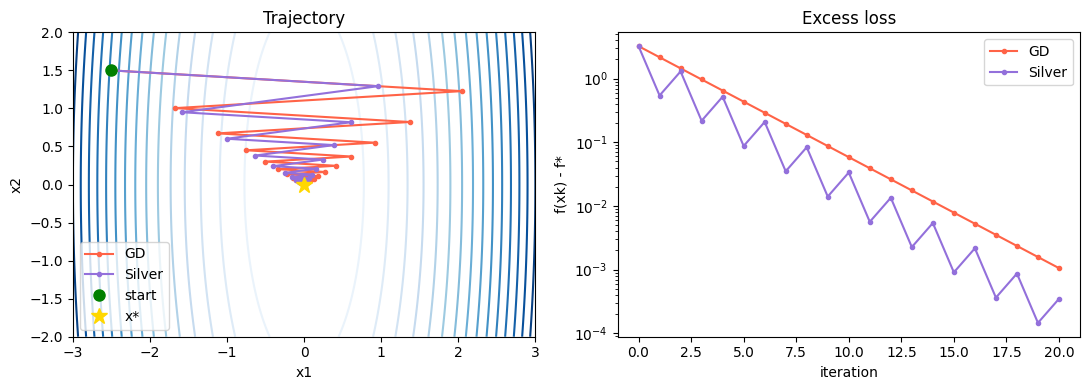

In [73]:
L, mu = 1., 0.1
kappa = mu / L
H = np.array([L, mu])
grad = lambda x: H * x
f = lambda x: 0.5 * (H * x**2).sum()

def run_gd(x0, T):
    x, traj = x0.copy(), [x0.copy()]
    gamma = 2 / (L + mu)
    for _ in range(T):
        x -= gamma * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def run_silver(x0, T):
    x, traj = x0.copy(), [x0.copy()]
    gamma1 = (np.sqrt(1 + (1-kappa)**2) - kappa) / (L * (1 - kappa)) #TODO OPERAND
    gamma2 = (np.sqrt(1 + (1-kappa)**2) + 2 + kappa) / (L * (1 + 3*kappa)) #TODO OPERAND
    for _ in range(T):
        x -= gamma1 * grad(x); traj.append(x.copy())
        x -= gamma2 * grad(x); traj.append(x.copy())
    return np.array(traj)

x0 = np.array([-2.5, 1.5])
traj_gd     = run_gd(x0, T=20)
traj_silver = run_silver(x0, T=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

X, Y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 200))
ax1.contour(X, Y, 0.5*(H[0]*X**2 + H[1]*Y**2), levels=15, cmap="Blues")
for traj, color, label in [(traj_gd, "tomato", "GD"), (traj_silver, "mediumpurple", "Silver")]:
    ax1.plot(traj[:, 0], traj[:, 1], "o-", color=color, ms=3, label=label)
ax1.plot(*x0, "go", ms=8, label="start")
ax1.plot(0, 0, "*", color="gold", ms=12, label="x*")
ax1.set(title="Trajectory", xlabel="x1", ylabel="x2"); ax1.legend()

ax2.semilogy([f(x) for x in traj_gd],     "o-", color="tomato",       ms=3, label="GD")
ax2.semilogy([f(x) for x in traj_silver],  "o-", color="mediumpurple", ms=3, label="Silver")
ax2.set(title="Excess loss", xlabel="iteration", ylabel="f(xk) - f*"); ax2.legend()

plt.tight_layout(); plt.show()

### Going further <a class="anchor" id="sec4"></a>

More complete references and demos can be found in [PEPit's documentation and demos](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo).
- Algebraic techniques for solving linear matrix inequalities; see e.g., [3].
- Optimize over richer families of algorithms (e.g., families that include momentum?), see, e.g., [1, 3, 6, 7].
- Algorithm design based on nonlinear optimization; see, for instance, [6, 7].

---

### References

[1] Y. Drori and M. Teboulle, *Performance of first-order methods for smooth convex minimization: a novel approach*, Mathematical Programming, 2014. [arXiv:1206.3209](https://arxiv.org/abs/1206.3209)

[2] A. B. Taylor, J. M. Hendrickx, and F. Glineur, *Smooth strongly convex interpolation and exact worst-case performance of first-order methods*, Mathematical Programming, 2017. [arXiv:1502.05666](https://arxiv.org/abs/1502.05666)

[3] D. Kim and J. A. Fessler, *Optimized first-order methods for smooth convex minimization*, Mathematical Programming, 2016. [arXiv:1406.5468](https://arxiv.org/abs/1406.5468)

[4] S Naldi, MS El Din, A Taylor, W Wang, *Solving parametric linear matrix inequalities*, 2025. [HAL:05505762](https://hal.sorbonne-universite.fr/hal-05505762/document)

[5] J. M. Altschuler and P. A. Parrilo, *Acceleration by Stepsize Hedging I: Multi-Step Descent and the Silver Stepsize Schedule*, Journal of the ACM, 2025. [arXiv:2309.07879](https://arxiv.org/abs/2309.07879)

[6] S. Das Gupta, B. P. G. Van Parys, and E. K. Ryu, *Branch-and-bound performance estimation programming: a unified methodology for constructing optimal optimization methods*, Mathematical Programming, 2024. [arXiv:2203.07305](https://arxiv.org/abs/2203.07305)

[7] Y. Kamri, J. M. Hendrickx, and F. Glineur, *Numerical Design of Optimized First-Order Algorithms*, 2025. [arXiv:2507.20773](https://arxiv.org/abs/2507.20773)
